# Book Recommendation Model
User-based collaborative filtering with a content-based fallback for users with few ratings.

## 1. Load & Inspect the Data

In [1]:
import json
import pandas as pd
import numpy as np
from pandas import json_normalize
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

try:
    with open("bookworms_dataset.json", "r") as file:
        data = json.load(file)
except FileNotFoundError:
    print("file not found")
except json.JSONDecodeError:
    print("error decoding json")

books = pd.DataFrame(data["books"])
bookworms = pd.DataFrame(data["bookworms"])

# Flattened version — each preference/stat becomes its own column
bookworms_full = json_normalize(data["bookworms"])
bookworms_full.head(9)

,user_id,name,age,member_since,books_read,wishlist,location.city,location.country,location.timezone,preferences.favorite_genres,...,preferences.preferred_moods,preferences.preferred_length,preferences.preferred_era,reading_stats.total_books_read,reading_stats.reading_goal_per_year,reading_stats.books_read_this_year,reading_stats.avg_rating_given,reading_stats.longest_streak_days,reading_stats.most_read_genre,reading_stats.most_read_author_id
0,u001,Fadi,29,2021-03-15,"[{'book_id': 'b001', 'rating': 5, 'date_read':...","[{'book_id': 'b014', 'added_date': '2022-06-01...",Beirut,Lebanon,Asia/Beirut,"[dystopia, feminist, fiction]",...,"[dark, cerebral]",medium,"[modern, contemporary]",2,24,7,4.50,21,dystopia,a001
1,u002,Peggy,34,2020-07-01,"[{'book_id': 'b002', 'rating': 4, 'date_read':...","[{'book_id': 'b012', 'added_date': '2022-03-01...",Dublin,Ireland,Europe/Dublin,"[classic, romance, dystopia]",...,"[romantic, contemplative, dark]",long,"[classic, modern]",3,30,12,4.67,45,classic,a001
2,u003,Amara,26,2022-01-20,"[{'book_id': 'b023', 'rating': 5, 'date_read':...","[{'book_id': 'b047', 'added_date': '2022-10-01...",Lagos,Nigeria,Africa/Lagos,"[fiction, historical, feminist]",...,"[uplifting, cerebral]",medium,"[modern, contemporary]",4,20,5,4.50,14,fiction,a015
3,u004,Soren,41,2019-11-11,"[{'book_id': 'b005', 'rating': 5, 'date_read':...","[{'book_id': 'b042', 'added_date': '2022-05-01...",Copenhagen,Denmark,Europe/Copenhagen,"[sci-fi, dystopia, classic]",...,"[dark, adventurous, cerebral]",any,"[classic, modern]",6,40,18,4.33,90,dystopia,a004
4,u005,Lena,31,2021-06-30,"[{'book_id': 'b033', 'rating': 5, 'date_read':...","[{'book_id': 'b030', 'added_date': '2022-11-01...",Berlin,Germany,Europe/Berlin,"[fiction, drama, mental-health]",...,"[dark, contemplative]",long,"[modern, classic]",5,15,6,4.20,30,fiction,a019
5,u006,Tomás,38,2020-02-14,"[{'book_id': 'b007', 'rating': 5, 'date_read':...","[{'book_id': 'b032', 'added_date': '2022-01-10...",Buenos Aires,Argentina,America/Argentina/Buenos_Aires,"[thriller, crime, fiction]",...,"[dark, adventurous]",long,"[modern, contemporary]",4,35,14,4.50,60,thriller,a020
6,u007,Yuki,27,2022-04-01,"[{'book_id': 'b016', 'rating': 5, 'date_read':...","[{'book_id': 'b035', 'added_date': '2023-01-25...",Tokyo,Japan,Asia/Tokyo,"[fiction, sci-fi, contemporary]",...,"[contemplative, romantic]",short,"[modern, contemporary]",4,18,4,4.50,10,fiction,a007
7,u008,Priya,33,2019-08-08,"[{'book_id': 'b012', 'rating': 5, 'date_read':...","[{'book_id': 'b020', 'added_date': '2022-05-01...",Mumbai,India,Asia/Kolkata,"[classic, romance, coming-of-age]",...,"[romantic, uplifting, contemplative]",medium,[classic],6,25,10,4.50,50,classic,a011
8,u009,Kwame,45,2018-05-22,"[{'book_id': 'b022', 'rating': 5, 'date_read':...","[{'book_id': 'b047', 'added_date': '2022-07-01...",Accra,Ghana,Africa/Accra,"[historical, fiction, drama]",...,"[cerebral, dark, uplifting]",long,"[classic, modern]",7,20,8,4.57,120,historical,a024


In [2]:
print("Books shape:", books.shape)
print("Bookworms shape:", bookworms.shape)
print("\nBooks columns:", books.columns.tolist())
print("\nBookworms columns:", bookworms_full.columns.tolist())

Books shape: (50, 10)
Bookworms shape: (15, 9)

Books columns: ['book_id', 'title', 'author', 'author_id', 'genres', 'year', 'pages', 'avg_rating', 'language', 'isbn']

Bookworms columns: ['user_id', 'name', 'age', 'member_since', 'books_read', 'wishlist', 'location.city', 'location.country', 'location.timezone', 'preferences.favorite_genres', 'preferences.disliked_genres', 'preferences.favorite_authors', 'preferences.reading_pace', 'preferences.preferred_moods', 'preferences.preferred_length', 'preferences.preferred_era', 'reading_stats.total_books_read', 'reading_stats.reading_goal_per_year', 'reading_stats.books_read_this_year', 'reading_stats.avg_rating_given', 'reading_stats.longest_streak_days', 'reading_stats.most_read_genre', 'reading_stats.most_read_author_id']


## 2. Flatten Ratings into an Interactions Table

In [3]:
# Each row = one rating event: who rated what, and how much
ratings_rows = []

for user in data["bookworms"]:
    for entry in user["books_read"]:
        ratings_rows.append({
            "user_id":   user["user_id"],
            "user_name": user["name"],
            "book_id":   entry["book_id"],
            "rating":    entry["rating"],
            "reread":    entry["reread"],          # strong positive signal
            "dnf":       entry["did_not_finish"],  # negative signal
            "date_read": entry["date_read"],
        })

ratings = pd.DataFrame(ratings_rows)

# Boost reread ratings slightly — a reread means they really loved it
ratings["adjusted_rating"] = ratings.apply(
    lambda row: min(row["rating"] + 0.5, 5.0) if row["reread"] else row["rating"], axis=1
)

# Penalise did-not-finish
ratings["adjusted_rating"] = ratings.apply(
    lambda row: max(row["adjusted_rating"] - 1.0, 1.0) if row["dnf"] else row["adjusted_rating"], axis=1
)

print(f"Total ratings: {len(ratings)}")
ratings.head(10)

Total ratings: 78


,user_id,user_name,book_id,rating,reread,dnf,date_read,adjusted_rating
0,u001,Fadi,b001,5,False,False,2022-01-10,5.0
1,u001,Fadi,b003,4,False,False,2022-04-22,4.0
2,u002,Peggy,b002,4,False,False,2021-06-05,4.0
3,u002,Peggy,b001,5,True,False,2021-08-18,5.0
4,u002,Peggy,b004,5,True,False,2022-02-14,5.0
5,u003,Amara,b023,5,False,False,2022-03-01,5.0
6,u003,Amara,b025,5,False,False,2022-05-10,5.0
7,u003,Amara,b026,4,False,False,2022-07-22,4.0
8,u003,Amara,b024,4,False,False,2023-01-03,4.0
9,u004,Soren,b005,5,True,False,2020-01-15,5.0


## 3. Exploratory Data Analysis (EDA)

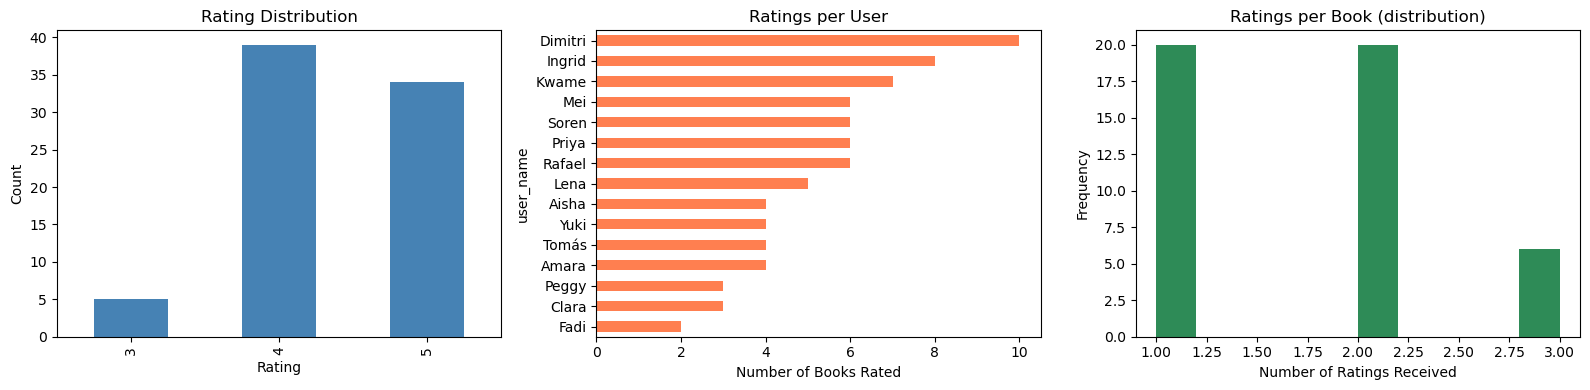

Users: 15 | Books rated: 46 | Total possible pairs: 690
Sparsity: 88.70% of the matrix is empty


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Rating Distribution")
axes[0].set_xlabel("Rating")
axes[0].set_ylabel("Count")

# Ratings per user
ratings.groupby("user_name").size().sort_values().plot(kind="barh", ax=axes[1], color="coral")
axes[1].set_title("Ratings per User")
axes[1].set_xlabel("Number of Books Rated")

# Ratings per book
ratings.groupby("book_id").size().plot(kind="hist", bins=10, ax=axes[2], color="seagreen")
axes[2].set_title("Ratings per Book (distribution)")
axes[2].set_xlabel("Number of Ratings Received")

plt.tight_layout()
plt.show()

# Sparsity — how much of the matrix is empty?
n_users = ratings["user_id"].nunique()
n_books = ratings["book_id"].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_books))
print(f"Users: {n_users} | Books rated: {n_books} | Total possible pairs: {n_users * n_books}")
print(f"Sparsity: {sparsity:.2%} of the matrix is empty")

## 4. Build the User–Item Matrix

In [5]:
# Rows = users, columns = books, values = adjusted ratings (0 means not rated)
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="book_id",
    values="adjusted_rating",
    fill_value=0
)

print("User-item matrix shape:", user_item_matrix.shape)
user_item_matrix

User-item matrix shape: (15, 46)


book_id,b001,b002,b003,b004,b005,b006,b007,b008,b009,b010,...,b041,b042,b043,b044,b045,b046,b047,b048,b049,b050
user_id,,,,,,,,,,,,,,,,,,,,,
u001,5.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u002,5.0,4.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u004,0.0,4.0,0.0,0.0,5.0,4.0,0.0,4.0,5.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u005,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u006,0.0,0.0,0.0,0.0,4.0,0.0,5.0,0.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u007,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u008,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
u009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 5. Feature Engineering (Content-Based Signals)

In [6]:
# --- Genre overlap between user preferences and each book ---
# MultiLabelBinarizer turns lists like ["dystopia","sci-fi"] into binary columns

mlb = MultiLabelBinarizer()

# Encode book genres
book_genre_matrix = pd.DataFrame(
    mlb.fit_transform(books["genres"]),
    index=books["book_id"],
    columns=mlb.classes_
)

# Encode user preferred genres using the same vocabulary
user_genre_prefs = {}
for user in data["bookworms"]:
    fav = set(user["preferences"]["favorite_genres"])
    disliked = set(user["preferences"]["disliked_genres"])
    user_genre_prefs[user["user_id"]] = {"favorite": fav, "disliked": disliked}

def genre_overlap_score(user_id, book_id):
    """Returns a score: +1 per matching favorite genre, -0.5 per disliked genre."""
    if book_id not in book_genre_matrix.index:
        return 0
    book_genres = set(books.loc[books["book_id"] == book_id, "genres"].values[0])
    prefs = user_genre_prefs.get(user_id, {})
    overlap = len(book_genres & prefs.get("favorite", set()))
    dislike  = len(book_genres & prefs.get("disliked", set()))
    return overlap - (0.5 * dislike)

# --- Author affinity ---
# Has this user rated other books by the same author, and how highly?
book_author_map = books.set_index("book_id")["author_id"].to_dict()

def author_affinity_score(user_id, book_id):
    """Mean rating the user gave to other books by the same author."""
    target_author = book_author_map.get(book_id)
    if not target_author:
        return 0
    user_ratings = ratings[ratings["user_id"] == user_id]
    # Books by the same author this user has already rated
    same_author_books = [
        bid for bid in user_ratings["book_id"].values
        if book_author_map.get(bid) == target_author and bid != book_id
    ]
    if not same_author_books:
        return 0
    return user_ratings[user_ratings["book_id"].isin(same_author_books)]["rating"].mean()

# --- Wishlist signal ---
# Users have already expressed intent — treat this as implicit positive interest
wishlist_lookup = {}
for user in data["bookworms"]:
    wishlist_lookup[user["user_id"]] = {
        item["book_id"]: item["priority"] for item in user.get("wishlist", [])
    }

priority_score = {"high": 1.0, "medium": 0.5, "low": 0.2}

def wishlist_score(user_id, book_id):b
    priority = wishlist_lookup.get(user_id, {}).get(book_id)
    return priority_score.get(priority, 0)

print("Feature engineering functions ready.")
print("Example — genre overlap for u001 on b005:", genre_overlap_score("u001", "b005"))
print("Example — author affinity for u002 on b014:", author_affinity_score("u002", "b014"))
print("Example — wishlist score for u001 on b014:", wishlist_score("u001", "b014"))

Feature engineering functions ready.
Example — genre overlap for u001 on b005: 1.0
Example — author affinity for u002 on b014: 4.5
Example — wishlist score for u001 on b014: 1.0


## 6. Train/Test Split

In [7]:
# Hold out 20% of ratings to evaluate predictions against
# stratify by user so every user appears in both train and test
train_df, test_df = train_test_split(
    ratings,
    test_size=0.2,
    random_state=42,
    stratify=ratings["user_id"]
)

print(f"Training ratings: {len(train_df)}")
print(f"Test ratings:     {len(test_df)}")

# Build the training matrix only
train_matrix = train_df.pivot_table(
    index="user_id",
    columns="book_id",
    values="adjusted_rating",
    fill_value=0
)

Training ratings: 62
Test ratings:     16


## 7. User-Based Collaborative Filtering

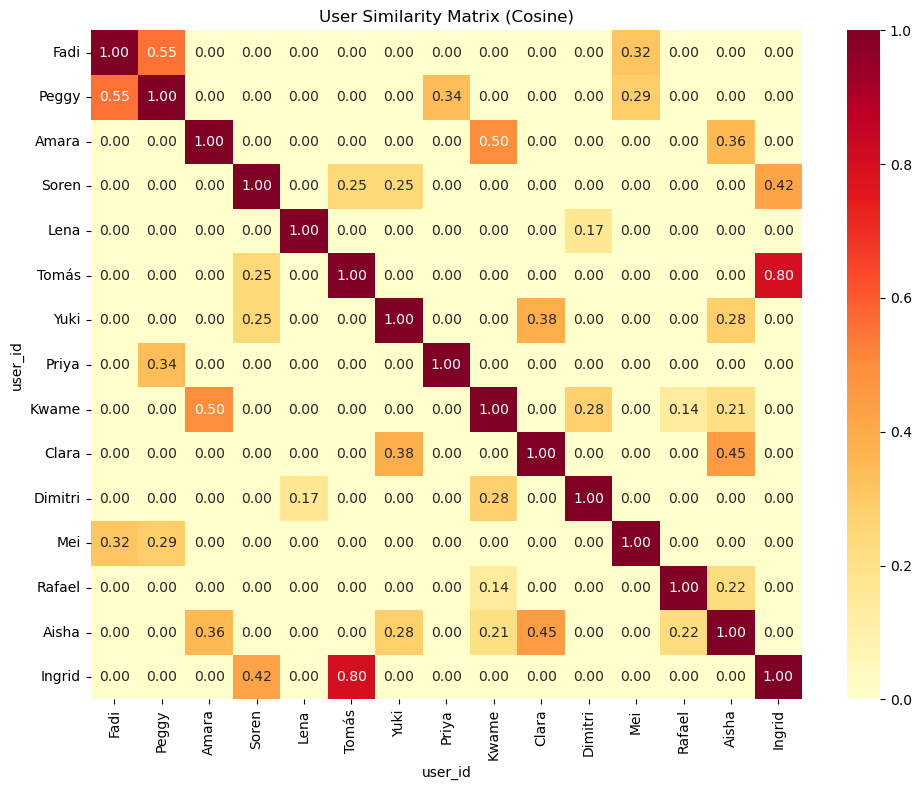

In [8]:
# Compute cosine similarity between every pair of users
# Result: matrix where entry [i,j] = how similar user i is to user j (0 to 1)
user_similarity = cosine_similarity(train_matrix)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=train_matrix.index,
    columns=train_matrix.index
)

# Visualise the similarity heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    user_similarity_df,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    xticklabels=[
        next(u["name"] for u in data["bookworms"] if u["user_id"] == uid)
        for uid in user_similarity_df.index
    ],
    yticklabels=[
        next(u["name"] for u in data["bookworms"] if u["user_id"] == uid)
        for uid in user_similarity_df.index
    ]
)
plt.title("User Similarity Matrix (Cosine)")
plt.tight_layout()
plt.show()

In [9]:
def predict_rating_cf(user_id, book_id, n_neighbors=5):
    """
    Predict what rating `user_id` would give `book_id`.
    Uses the weighted average of the top N most similar users who rated that book.
    Falls back to the book's global average if no neighbors have rated it.
    """
    if user_id not in user_similarity_df.index:
        return None
    if book_id not in train_matrix.columns:
        # Book has no ratings in training set — fall back to global avg
        global_avg = books.loc[books["book_id"] == book_id, "avg_rating"]
        return float(global_avg.values[0]) if len(global_avg) else 3.0

    # Get similarity scores for all other users
    sims = user_similarity_df[user_id].drop(user_id)

    # Keep only users who actually rated this book
    rated_mask = train_matrix[book_id] > 0
    sims = sims[rated_mask]

    if sims.empty:
        global_avg = books.loc[books["book_id"] == book_id, "avg_rating"]
        return float(global_avg.values[0]) if len(global_avg) else 3.0

    # Top N neighbors
    top_neighbors = sims.nlargest(n_neighbors)

    # Weighted average: neighbors who are more similar carry more weight
    neighbor_ratings = train_matrix.loc[top_neighbors.index, book_id]
    weighted_sum = (top_neighbors * neighbor_ratings).sum()
    sim_sum = top_neighbors.abs().sum()

    if sim_sum == 0:
        return 3.0

    return round(weighted_sum / sim_sum, 3)


def predict_rating_hybrid(user_id, book_id, cf_weight=0.6, content_weight=0.4):
    """
    Blend collaborative filtering with content-based signals.
    CF captures taste from peers; content captures genre/author fit.
    """
    cf_score = predict_rating_cf(user_id, book_id) or 3.0

    # Content score: normalise genre + author + wishlist signals onto a 1–5 scale
    genre_s   = genre_overlap_score(user_id, book_id)    # roughly -1 to +3
    author_s  = author_affinity_score(user_id, book_id)  # 0 to 5
    wishlist_s = wishlist_score(user_id, book_id)        # 0 to 1

    # Map genre score to 1–5 range
    genre_rating = min(max(3.0 + genre_s, 1.0), 5.0)

    # Average content signals (author affinity only counts if available)
    if author_s > 0:
        content_score = (genre_rating + author_s) / 2
    else:
        content_score = genre_rating

    # Add wishlist bump
    content_score = min(content_score + wishlist_s, 5.0)

    hybrid = (cf_weight * cf_score) + (content_weight * content_score)
    return round(hybrid, 3)


# Quick sanity check
print("CF predicted rating for u001 on b005:",    predict_rating_cf("u001", "b005"))
print("Hybrid predicted rating for u001 on b005:", predict_rating_hybrid("u001", "b005"))

CF predicted rating for u001 on b005: 3.0
Hybrid predicted rating for u001 on b005: 3.6


## 8. Evaluate the Model

RMSE — Collaborative Filtering: 0.863
RMSE — Hybrid Model:            0.474
(Lower RMSE = predictions are closer to actual ratings)


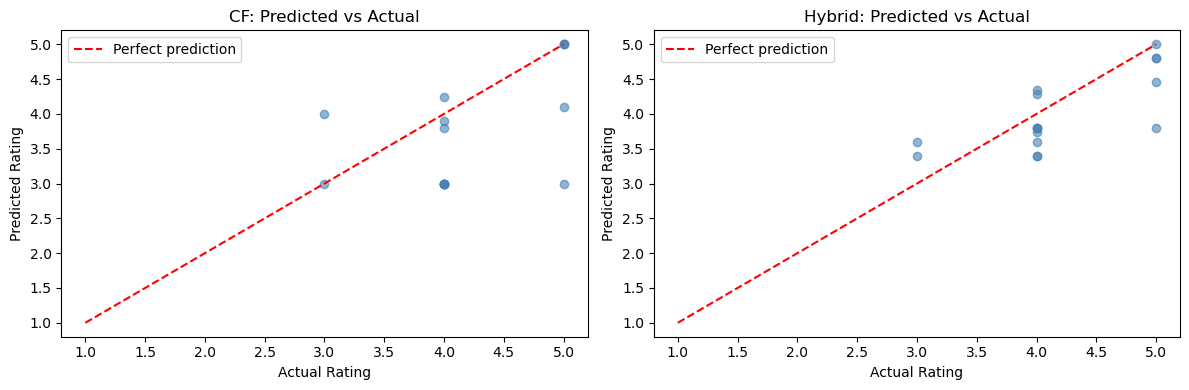

In [10]:
# Predict ratings for all held-out (test) user-book pairs
test_df = test_df.copy()
test_df["cf_predicted"]     = test_df.apply(lambda r: predict_rating_cf(r["user_id"], r["book_id"]),     axis=1)
test_df["hybrid_predicted"] = test_df.apply(lambda r: predict_rating_hybrid(r["user_id"], r["book_id"]), axis=1)

# Drop rows where prediction failed
eval_df = test_df.dropna(subset=["cf_predicted", "hybrid_predicted"])

rmse_cf     = np.sqrt(mean_squared_error(eval_df["rating"], eval_df["cf_predicted"]))
rmse_hybrid = np.sqrt(mean_squared_error(eval_df["rating"], eval_df["hybrid_predicted"]))

print(f"RMSE — Collaborative Filtering: {rmse_cf:.3f}")
print(f"RMSE — Hybrid Model:            {rmse_hybrid:.3f}")
print("(Lower RMSE = predictions are closer to actual ratings)")

# Visualise predicted vs actual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ["cf_predicted", "hybrid_predicted"], ["CF", "Hybrid"]):
    ax.scatter(eval_df["rating"], eval_df[col], alpha=0.6, color="steelblue")
    ax.plot([1, 5], [1, 5], "r--", label="Perfect prediction")
    ax.set_xlabel("Actual Rating")
    ax.set_ylabel("Predicted Rating")
    ax.set_title(f"{title}: Predicted vs Actual")
    ax.legend()
plt.tight_layout()
plt.show()

## 9. Generate Recommendations for Every Bookworm

In [11]:
# Build a quick lookup: user_id -> set of book_ids already read
already_read = {
    user["user_id"]: {entry["book_id"] for entry in user["books_read"]}
    for user in data["bookworms"]
}

all_book_ids = books["book_id"].tolist()
book_info    = books.set_index("book_id").to_dict(orient="index")
user_id_to_name = {u["user_id"]: u["name"] for u in data["bookworms"]}

def recommend_for_user(user_id, top_n=8):
    """Return top_n book recommendations for a user, ranked by hybrid score."""
    read = already_read.get(user_id, set())
    candidates = [bid for bid in all_book_ids if bid not in read]

    scored = []
    for book_id in candidates:
        score = predict_rating_hybrid(user_id, book_id)
        scored.append((book_id, score))

    scored.sort(key=lambda x: x[1], reverse=True)

    results = []
    for rank, (book_id, score) in enumerate(scored[:top_n], start=1):
        info = book_info.get(book_id, {})
        results.append({
            "rank":             rank,
            "book_id":         book_id,
            "title":           info.get("title"),
            "author":          info.get("author"),
            "genres":          info.get("genres"),
            "year":            info.get("year"),
            "pages":           info.get("pages"),
            "avg_rating":      info.get("avg_rating"),
            "predicted_score": score,
        })
    return results


# Build the full recommendations output
recommendations_output = []

for user in data["bookworms"]:
    uid   = user["user_id"]
    recs  = recommend_for_user(uid, top_n=8)
    recommendations_output.append({
        "user_id":         uid,
        "name":            user["name"],
        "recommendations": recs,
    })

# Preview one user
pd.DataFrame(recommendations_output[0]["recommendations"])

,rank,book_id,title,author,genres,year,pages,avg_rating,predicted_score
0,1,b042,The Dispossessed,Ursula K. Le Guin,"[sci-fi, fiction, dystopia]",1974,341,4.2,5.00
1,2,b044,Parable of the Sower,Octavia Butler,"[dystopia, sci-fi, fiction]",1993,345,4.3,5.00
2,3,b014,The Testaments,Margaret Atwood,"[dystopia, fiction, feminist]",2019,419,4.2,4.52
3,4,b041,The Left Hand of Darkness,Ursula K. Le Guin,"[sci-fi, fiction, feminist]",1969,304,4.1,4.46
4,5,b004,Jane Eyre,Charlotte Brontë,"[classic, romance, fiction]",1847,532,4.2,4.40
5,6,b010,Station Eleven,Emily St. John Mandel,"[dystopia, fiction, sci-fi]",2014,333,4.0,4.40
6,7,b015,MaddAddam,Margaret Atwood,"[sci-fi, dystopia, fiction]",2013,394,4.0,4.40
7,8,b018,Alias Grace,Margaret Atwood,"[historical, fiction, thriller]",1996,468,4.1,4.26


## 10. Export Recommendations to JSON

In [12]:
output = {
    "model": {
        "algorithm":       "hybrid (user-based CF + content-based)",
        "cf_weight":        0.6,
        "content_weight":   0.4,
        "similarity_metric": "cosine",
        "rmse_cf":          round(rmse_cf, 4),
        "rmse_hybrid":      round(rmse_hybrid, 4),
    },
    "bookworms": recommendations_output,
}

with open("recommendations.json", "w") as f:
    json.dump(output, f, indent=2)

print("recommendations.json saved.")
print(f"Generated recommendations for {len(recommendations_output)} bookworms.")

recommendations.json saved.
Generated recommendations for 15 bookworms.
